# What diseases are in MIMIC-IV? An ICD analysis

This notebook answers, from the data rather than from memory:

1. **What does an ICD code actually tell you?**
2. **What is the hierarchy** — chapter, block, category, code — and what does each level add?
3. **How many broad chapters** appear in MIMIC, and **how many unique codes sit in each**?
4. **Do patients have one disease or many?** With real worked examples of both.
5. **How far does one patient's diagnosis set spread** across the hierarchy?
6. **Which conditions travel together?**

It reads only two tables from the MIMIC-IV `hosp` module — `diagnoses_icd` and
`d_icd_diagnoses` — and optionally `admissions` for patient counts. Everything else is derived.

> **Attach the data first.** In the Kaggle editor use **+ Add Input** and attach a MIMIC-IV
> dataset. The next cell finds the files wherever they landed, so no path editing is needed.
> The MIMIC-IV demo (~100 patients) works and runs in seconds; the full credentialed dataset
> gives the real numbers. The notebook reports which one it is reading.

## 0. Locate and load the data

In [1]:
import os, re, glob, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)

SEARCH_ROOTS = ["/kaggle/input", "../input", "./data", ".","/kaggle/input/datasets/akshaybe/updated-mimic-iv/mimic-iv-3.1/hosp"]

def find_table(*names):
    """
    Locate a MIMIC table by name, whatever the dataset's folder layout is.

    Kaggle mirrors of MIMIC differ in nesting and compression, so every root is
    searched recursively for csv / csv.gz / parquet, and the largest match wins
    -- a 'sample_' file usually sits next to the real one and is far smaller.
    """
    hits = []
    for root in SEARCH_ROOTS:
        if not os.path.isdir(root):
            continue
        for name in names:
            for ext in ("csv", "csv.gz", "parquet"):
                hits += glob.glob(f"{root}/**/{name}.{ext}", recursive=True)
    if not hits:
        return None
    return max(set(hits), key=os.path.getsize)

def read_table(path, **kw):
    if path.endswith(".parquet"):
        return pd.read_parquet(path, **({"columns": kw["usecols"]} if "usecols" in kw else {}))
    return pd.read_csv(path, **kw)

dx_path  = find_table("diagnoses_icd", "sample_diagnoses_icd")
dic_path = find_table("d_icd_diagnoses", "sample_d_icd_diagnoses")
adm_path = find_table("admissions", "sample_admissions")

print("diagnoses_icd   :", dx_path or "NOT FOUND")
print("d_icd_diagnoses :", dic_path or "NOT FOUND")
print("admissions      :", adm_path or "not found (optional)")

if not dx_path or not dic_path:
    raise SystemExit(
        "Attach a MIMIC-IV dataset with + Add Input. Needs diagnoses_icd and d_icd_diagnoses."
    )

diagnoses_icd   : ../input/datasets/akshaybe/updated-mimic-iv/mimic-iv-3.1/hosp/diagnoses_icd.csv
d_icd_diagnoses : ../input/datasets/akshaybe/updated-mimic-iv/mimic-iv-3.1/hosp/d_icd_diagnoses.csv
admissions      : /kaggle/input/datasets/akshaybe/updated-mimic-iv/mimic-iv-3.1/hosp/admissions.csv


In [2]:
dx = read_table(dx_path, usecols=["subject_id", "hadm_id", "seq_num", "icd_code", "icd_version"])
dic = read_table(dic_path, usecols=["icd_code", "icd_version", "long_title"])

# The two tables disagree on padding and case in some releases, and the same
# string is a valid code in BOTH ICD versions meaning different things -- so the
# join key is always the (code, version) PAIR, never the code alone.
for frame in (dx, dic):
    frame["icd_code"] = frame["icd_code"].astype(str).str.strip().str.upper()
    frame["icd_version"] = pd.to_numeric(frame["icd_version"], errors="coerce").astype("Int64")

dic = dic.drop_duplicates(subset=["icd_code", "icd_version"])
before = len(dx)
dx = dx.merge(dic, on=["icd_code", "icd_version"], how="left")
assert len(dx) == before, "the dictionary join duplicated rows"

unmapped = dx.long_title.isna().mean()
dx["long_title"] = dx.long_title.fillna("Unmapped ICD code " + dx.icd_code)

scale = "FULL MIMIC-IV" if len(dx) > 500_000 else ("DEMO subset" if len(dx) > 500 else "SAMPLE file")
print(f"reading: {scale}")
print(f"  diagnosis rows : {len(dx):,}")
print(f"  admissions     : {dx.hadm_id.nunique():,}")
print(f"  patients       : {dx.subject_id.nunique():,}")
print(f"  unmapped codes : {unmapped:.2%}")
dx.head(8)

reading: FULL MIMIC-IV
  diagnosis rows : 6,364,488
  admissions     : 545,497
  patients       : 223,291
  unmapped codes : 0.00%


,subject_id,hadm_id,seq_num,icd_code,icd_version,long_title
0,10000032,22595853,1,5723,9,Portal hypertension
1,10000032,22595853,2,78959,9,Other ascites
2,10000032,22595853,3,5715,9,Cirrhosis of liver without mention of alcohol
3,10000032,22595853,4,07070,9,Unspecified viral hepatitis C without hepatic coma
4,10000032,22595853,5,496,9,"Chronic airway obstruction, not elsewhere classified"
5,10000032,22595853,6,29680,9,"Bipolar disorder, unspecified"
6,10000032,22595853,7,30981,9,Posttraumatic stress disorder
7,10000032,22595853,8,V1582,9,Personal history of tobacco use


## 1. What does an ICD code actually tell you?

A row of `diagnoses_icd` carries four things, and each answers a different question:

| Field | Question it answers |
|---|---|
| `icd_code` | **What** condition — the diagnosis itself |
| `icd_version` | **Which dictionary** the code belongs to, 9 or 10. The same string means different things in each |
| `seq_num` | **How central** it was to this stay. `1` is the *principal* diagnosis, the condition chiefly responsible for the admission |
| `hadm_id` | **Which stay** it was coded on — codes belong to an admission, not to a person |

Two things an ICD code does **not** tell you:

- **Severity.** Two patients with the same code can be worlds apart clinically.
- **When it started.** A code on this admission may be a chronic condition of twenty years'
  standing or something that developed yesterday. Discharge coding does not distinguish them.

The code string itself is structured. Reading `I50.23`:

```
I        chapter letter        diseases of the circulatory system
I50      three-char category   heart failure
I50.2    subcategory           systolic (congestive) heart failure
I50.23   full code             acute on chronic systolic heart failure
```

Each character to the right narrows the meaning. ICD-10 uses those trailing characters for
laterality, episode of care and severity, which is why one clinical concept can occupy dozens of
codes.

In [3]:
# One admission, exactly as MIMIC stores it. seq_num 1 is the principal diagnosis.
sizes = dx.groupby("hadm_id").size()
demo_hadm = sizes[(sizes >= 8) & (sizes <= 14)].index[0] if ((sizes >= 8) & (sizes <= 14)).any() \
            else sizes.idxmax()

one = dx[dx.hadm_id == demo_hadm].sort_values("seq_num")
print(f"admission {demo_hadm} -- {len(one)} diagnoses coded\n")
for _, r in one.iterrows():
    role = "PRINCIPAL" if r.seq_num == 1 else f"seq {int(r.seq_num)}"
    print(f"  {role:<10} {r.icd_code:<9} ICD-{r.icd_version}  {r.long_title[:88]}")

admission 20000019 -- 12 diagnoses coded

  PRINCIPAL  0389      ICD-9  Unspecified septicemia
  seq 2      59080     ICD-9  Pyelonephritis, unspecified
  seq 3      75310     ICD-9  Cystic kidney disease, unspecified
  seq 4      5849      ICD-9  Acute kidney failure, unspecified
  seq 5      2761      ICD-9  Hyposmolality and/or hyponatremia
  seq 6      99591     ICD-9  Sepsis
  seq 7      25000     ICD-9  Diabetes mellitus without mention of complication, type II or unspecified type, not stat
  seq 8      4019      ICD-9  Unspecified essential hypertension
  seq 9      49390     ICD-9  Asthma, unspecified type, unspecified
  seq 10     2724      ICD-9  Other and unspecified hyperlipidemia
  seq 11     V1649     ICD-9  Family history of malignant neoplasm of other genital organs
  seq 12     2859      ICD-9  Anemia, unspecified


## 2. The hierarchy

ICD is a tree. Four levels matter here:

```
Chapter      Diseases of the circulatory system      I00-I99     ~20 of these exist
  Block      Heart failure and other heart disease   I30-I52     a published grouping
    Category Heart failure                           I50         the 3-character stem
      Code   Acute on chronic systolic HF            I50.23      what gets stored
```

The mapping below is applied to every code in the data. ICD-9 and ICD-10 divide the body
differently and name the same chapter differently, so equivalent chapters are merged onto one
canonical label — otherwise every chapter appears twice purely because of the coding era.

In [4]:
ICD10_CHAPTERS = [
    ("A00","B99","Infectious and parasitic diseases"),
    ("C00","D49","Neoplasms"),
    ("D50","D89","Blood and immune mechanism"),
    ("E00","E89","Endocrine, nutritional and metabolic"),
    ("F01","F99","Mental, behavioural and neurodevelopmental"),
    ("G00","G99","Nervous system and sense organs"),
    ("H00","H59","Nervous system and sense organs"),
    ("H60","H95","Nervous system and sense organs"),
    ("I00","I99","Circulatory system"),
    ("J00","J99","Respiratory system"),
    ("K00","K95","Digestive system"),
    ("L00","L99","Skin and subcutaneous tissue"),
    ("M00","M99","Musculoskeletal system and connective tissue"),
    ("N00","N99","Genitourinary system"),
    ("O00","O9A","Pregnancy, childbirth and the puerperium"),
    ("P00","P96","Perinatal conditions"),
    ("Q00","Q99","Congenital malformations"),
    ("R00","R99","Symptoms, signs and abnormal findings"),
    ("S00","T88","Injury and poisoning"),
    ("U00","U85","Codes for special purposes, incl. COVID-19"),
    ("V00","Y99","External causes of morbidity"),
    ("Z00","Z99","Factors influencing health status"),
]

ICD9_CHAPTERS = [
    (1,139,"Infectious and parasitic diseases"),
    (140,239,"Neoplasms"),
    (240,279,"Endocrine, nutritional and metabolic"),
    (280,289,"Blood and immune mechanism"),
    (290,319,"Mental, behavioural and neurodevelopmental"),
    (320,389,"Nervous system and sense organs"),
    (390,459,"Circulatory system"),
    (460,519,"Respiratory system"),
    (520,579,"Digestive system"),
    (580,629,"Genitourinary system"),
    (630,679,"Pregnancy, childbirth and the puerperium"),
    (680,709,"Skin and subcutaneous tissue"),
    (710,739,"Musculoskeletal system and connective tissue"),
    (740,759,"Congenital malformations"),
    (760,779,"Perinatal conditions"),
    (780,799,"Symptoms, signs and abnormal findings"),
    (800,999,"Injury and poisoning"),
]

def chapter_of(code, version):
    """
    Chapter for one (code, version) pair.

    Version is taken from the data rather than guessed from the string, which
    matters: 'E6601' is obesity in ICD-10 and an external-cause code in ICD-9,
    and only the version field separates them.
    """
    c = str(code).strip().upper()
    if not c:
        return "Not coded"
    if version == 9:
        if c[0] == "E":
            return "External causes of morbidity"
        if c[0] == "V":
            return "Factors influencing health status"
        try:
            head = int(c[:3])
        except ValueError:
            return "Unclassified"
        for lo, hi, name in ICD9_CHAPTERS:
            if lo <= head <= hi:
                return name
        return "Unclassified"
    head = c[:3]
    for lo, hi, name in ICD10_CHAPTERS:
        if lo <= head <= hi:
            return name
    return "Unclassified"

dx["chapter"] = [chapter_of(c, v) for c, v in zip(dx.icd_code, dx.icd_version)]
dx["category"] = dx.icd_code.str.slice(0, 3)          # the 3-character stem
print("codes that could not be placed in a chapter:",
      f"{(dx.chapter == 'Unclassified').mean():.3%}")
dx[["icd_code", "icd_version", "category", "chapter", "long_title"]].head(6)

codes that could not be placed in a chapter: 0.000%


,icd_code,icd_version,category,chapter,long_title
0,5723,9,572,Digestive system,Portal hypertension
1,78959,9,789,"Symptoms, signs and abnormal findings",Other ascites
2,5715,9,571,Digestive system,Cirrhosis of liver without mention of alcohol
3,07070,9,070,Infectious and parasitic diseases,Unspecified viral hepatitis C without hepatic coma
4,496,9,496,Respiratory system,"Chronic airway obstruction, not elsewhere classified"
5,29680,9,296,"Mental, behavioural and neurodevelopmental","Bipolar disorder, unspecified"


In [5]:
# The hierarchy, drilled through on real data. Blocks are a published grouping
# between chapter and category; the circulatory ones are listed here as the
# worked example rather than reproducing all ~280 from memory.
CIRC_BLOCKS = [
    ("I00","I02","Acute rheumatic fever"),
    ("I05","I09","Chronic rheumatic heart disease"),
    ("I10","I16","Hypertensive diseases"),
    ("I20","I25","Ischaemic heart diseases"),
    ("I26","I28","Pulmonary heart disease"),
    ("I30","I52","Other forms of heart disease"),
    ("I60","I69","Cerebrovascular diseases"),
    ("I70","I79","Arteries, arterioles and capillaries"),
    ("I80","I89","Veins, lymphatics and lymph nodes"),
    ("I95","I99","Other and unspecified circulatory disorders"),
]

def block_of(code):
    head = str(code)[:3].upper()
    for lo, hi, name in CIRC_BLOCKS:
        if lo <= head <= hi:
            return f"{lo}-{hi}  {name}"
    return None

circ10 = dx[(dx.chapter == "Circulatory system") & (dx.icd_version == 10)].copy()
circ10["block"] = circ10.icd_code.map(block_of)

print("CHAPTER  Circulatory system  (ICD-10 rows only)")
print(f"   {len(circ10):,} diagnosis rows, {circ10.icd_code.nunique():,} distinct codes, "
      f"{circ10.category.nunique():,} categories\n")
print("  BLOCKS")
for blk, g in circ10.groupby("block"):
    print(f"    {blk:<52} {g.icd_code.nunique():>4} codes  {len(g):>7,} rows")

print("\n  CATEGORY I50 (heart failure) drilled to full codes:")
hf = circ10[circ10.category == "I50"]
for code, g in sorted(hf.groupby("icd_code"), key=lambda kv: -len(kv[1])):
    print(f"    {code:<8} {len(g):>7,} rows   {g.long_title.iloc[0][:72]}")

CHAPTER  Circulatory system  (ICD-10 rows only)
   486,103 diagnosis rows, 1,059 distinct codes, 76 categories

  BLOCKS
    I00-I02  Acute rheumatic fever                          3 codes       19 rows
    I05-I09  Chronic rheumatic heart disease               25 codes    6,677 rows
    I10-I16  Hypertensive diseases                         17 codes  139,717 rows
    I20-I25  Ischaemic heart diseases                      63 codes   83,035 rows
    I26-I28  Pulmonary heart disease                       25 codes   15,206 rows
    I30-I52  Other forms of heart disease                 132 codes  144,593 rows
    I60-I69  Cerebrovascular diseases                     319 codes   27,324 rows
    I70-I79  Arteries, arterioles and capillaries         199 codes   21,410 rows
    I80-I89  Veins, lymphatics and lymph nodes            226 codes   22,617 rows
    I95-I99  Other and unspecified circulatory disorders   49 codes   25,359 rows

  CATEGORY I50 (heart failure) drilled to full codes:
    

## 3. How many chapters, and how many unique codes in each?

This is the headline table: every chapter present in the data, how many **distinct codes** it
contains, how many **admissions** carry at least one of them, and how many **patients**.

Note that admissions counts sum to far more than the number of admissions — an admission
appears in every chapter it touches, which is the whole point of section 5.

In [6]:
per_chapter = (dx.groupby("chapter")
                 .agg(distinct_codes=("icd_code", "nunique"),
                      categories=("category", "nunique"),
                      diagnosis_rows=("icd_code", "size"),
                      admissions=("hadm_id", "nunique"),
                      patients=("subject_id", "nunique"))
                 .sort_values("diagnosis_rows", ascending=False))

per_chapter["pct_of_admissions"] = (
    per_chapter.admissions / dx.hadm_id.nunique() * 100).round(1)

print(f"chapters present : {len(per_chapter)}")
print(f"distinct codes   : {dx.icd_code.nunique():,}")
print(f"distinct (code, version) pairs : {dx.groupby(['icd_code','icd_version']).ngroups:,}")
print(f"distinct categories : {dx.category.nunique():,}\n")
per_chapter

chapters present : 20
distinct codes   : 28,562
distinct (code, version) pairs : 28,583
distinct categories : 2,622



,distinct_codes,categories,diagnosis_rows,admissions,patients,pct_of_admissions
chapter,,,,,,
Factors influencing health status,1626,160,1046990,396656,165344,72.7
Circulatory system,1513,135,968975,353086,141495,64.7
"Endocrine, nutritional and metabolic",807,106,747220,342417,140994,62.8
"Symptoms, signs and abnormal findings",921,107,469646,264215,133651,48.4
"Mental, behavioural and neurodevelopmental",948,99,423435,238565,107956,43.7
Digestive system,1105,121,415596,230998,104073,42.3
Nervous system and sense organs,2425,193,309276,203215,96119,37.3
Genitourinary system,855,130,297560,190389,86283,34.9
External causes of morbidity,1779,228,244802,150534,92631,27.6


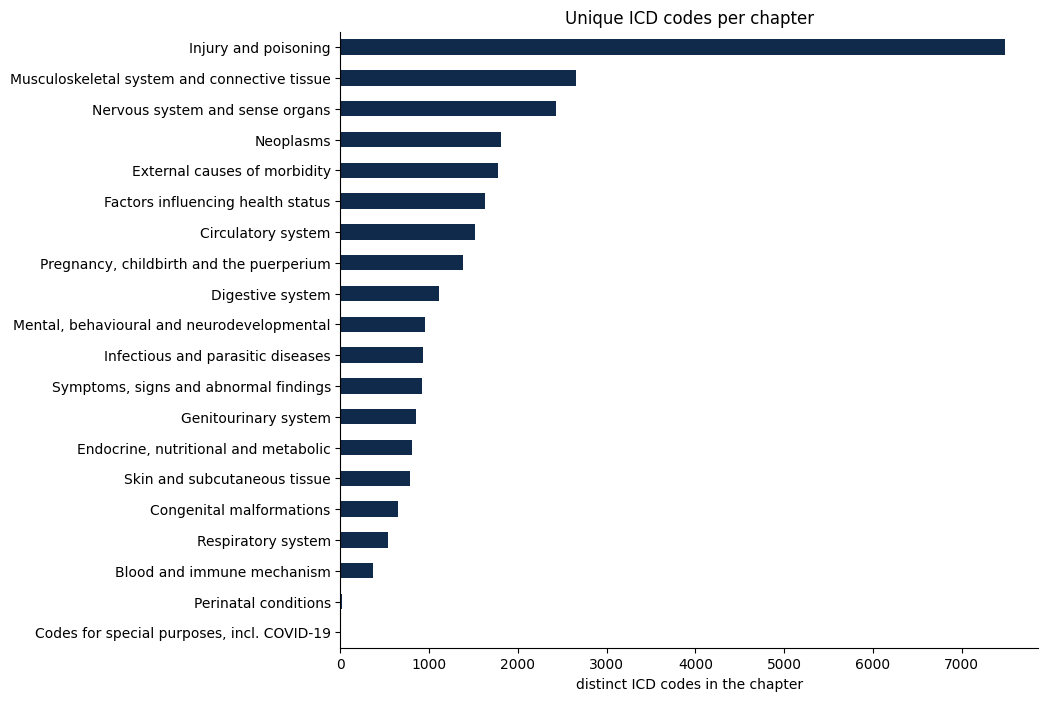

In [7]:
# Where the codes are, versus where the patients are. A chapter can hold a huge
# number of rarely-used codes, or a handful of codes that nearly everyone gets.
fig_data = per_chapter.sort_values("distinct_codes", ascending=True)
ax = fig_data[["distinct_codes"]].plot(
    kind="barh", figsize=(9, 8), legend=False, color="#0F2A4A")
ax.set_xlabel("distinct ICD codes in the chapter")
ax.set_ylabel("")
ax.set_title("Unique ICD codes per chapter")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

In [8]:
# ICD-9 vs ICD-10. MIMIC-IV spans the 2015 US transition, so both are present
# and the same condition appears under two different codes depending on the year.
ver = (dx.groupby("icd_version")
         .agg(rows=("icd_code", "size"), distinct_codes=("icd_code", "nunique"),
              admissions=("hadm_id", "nunique")))
ver["pct_of_rows"] = (ver.rows / len(dx) * 100).round(1)
print(ver, "\n")

both = (dx.groupby("long_title").icd_version.nunique() > 1).sum()
print(f"diagnosis titles that appear under BOTH ICD-9 and ICD-10: {both:,}")
print("-> the same clinical concept, split across two codes purely by coding era")

                rows  distinct_codes  admissions  pct_of_rows
icd_version                                                  
9            2908741            9143      291130         45.7
10           3455747           19440      254377         54.3 

diagnosis titles that appear under BOTH ICD-9 and ICD-10: 1,332
-> the same clinical concept, split across two codes purely by coding era


## 4. The long tail

Most codes are rare. This matters directly for modelling: a code used by three admissions
cannot support a learned effect, which is why models built on this data almost always collapse
diagnoses into counts or comorbidity indices rather than using the codes as features.

In [9]:
code_freq = dx.icd_code.value_counts()
n_adm = dx.hadm_id.nunique()

print(f"distinct codes                 : {len(code_freq):,}")
print(f"used on exactly ONE admission  : {(code_freq == 1).sum():,} "
      f"({(code_freq == 1).mean():.1%} of codes)")
print(f"used on 10 or fewer            : {(code_freq <= 10).sum():,} "
      f"({(code_freq <= 10).mean():.1%})")
print(f"used on 1% or more of admissions: {(code_freq >= n_adm * 0.01).sum():,}\n")

cum = code_freq.cumsum() / code_freq.sum()
for share in (0.5, 0.8, 0.9):
    k = int((cum <= share).sum()) + 1
    print(f"  the top {k:>5,} codes ({k/len(code_freq):>5.1%} of them) cover {share:.0%} of all diagnosis rows")

print("\nTOP 20 CODES OVERALL")
top = (dx.groupby(["icd_code", "icd_version", "long_title", "chapter"])
         .hadm_id.nunique().sort_values(ascending=False).head(20)
         .rename("admissions").reset_index())
top["pct_of_admissions"] = (top.admissions / n_adm * 100).round(1)
top

distinct codes                 : 28,562
used on exactly ONE admission  : 6,160 (21.6% of codes)
used on 10 or fewer            : 16,157 (56.6%)
used on 1% or more of admissions: 207

  the top   250 codes ( 0.9% of them) cover 50% of all diagnosis rows
  the top 1,293 codes ( 4.5% of them) cover 80% of all diagnosis rows
  the top 2,719 codes ( 9.5% of them) cover 90% of all diagnosis rows

TOP 20 CODES OVERALL


,icd_code,icd_version,long_title,chapter,admissions,pct_of_admissions
0,4019,9,Unspecified essential hypertension,Circulatory system,102362,18.8
1,E785,10,"Hyperlipidemia, unspecified","Endocrine, nutritional and metabolic",84568,15.5
2,I10,10,Essential (primary) hypertension,Circulatory system,83773,15.4
3,2724,9,Other and unspecified hyperlipidemia,"Endocrine, nutritional and metabolic",67288,12.3
4,Z87891,10,Personal history of nicotine dependence,Factors influencing health status,62803,11.5
5,K219,10,Gastro-esophageal reflux disease without esophagitis,Digestive system,56155,10.3
6,53081,9,Esophageal reflux,Digestive system,48624,8.9
7,25000,9,"Diabetes mellitus without mention of complication, type II or unspecified type, not st...","Endocrine, nutritional and metabolic",43076,7.9
8,F329,10,"Major depressive disorder, single episode, unspecified","Mental, behavioural and neurodevelopmental",41876,7.7
9,I2510,10,Atherosclerotic heart disease of native coronary artery without angina pectoris,Circulatory system,41548,7.6


In [10]:
# The top codes WITHIN each chapter -- what each broad category actually contains.
TOP_N = 5
for chapter in per_chapter.index[:10]:
    sub = dx[dx.chapter == chapter]
    counts = (sub.groupby(["icd_code", "long_title"]).hadm_id.nunique()
                 .sort_values(ascending=False).head(TOP_N))
    print(f"\n{chapter.upper()}  ({sub.icd_code.nunique():,} distinct codes)")
    for (c, t), n in counts.items():
        print(f"   {c:<9} {n:>8,} admissions   {t[:76]}")


FACTORS INFLUENCING HEALTH STATUS  (1,626 distinct codes)
   Z87891      62,803 admissions   Personal history of nicotine dependence
   Z20822      33,113 admissions   Contact with and (suspected) exposure to COVID-19
   V1582       31,704 admissions   Personal history of tobacco use
   Z7901       30,956 admissions   Long term (current) use of anticoagulants
   Z794        27,640 admissions   Long term (current) use of insulin

CIRCULATORY SYSTEM  (1,513 distinct codes)
   4019       102,362 admissions   Unspecified essential hypertension
   I10         83,773 admissions   Essential (primary) hypertension
   I2510       41,548 admissions   Atherosclerotic heart disease of native coronary artery without angina pecto
   42731       37,063 admissions   Atrial fibrillation
   4280        36,606 admissions   Congestive heart failure, unspecified

ENDOCRINE, NUTRITIONAL AND METABOLIC  (807 distinct codes)
   E785        84,568 admissions   Hyperlipidemia, unspecified
   2724        67,288 

## 5. One disease or many?

The central question. `seq_num = 1` marks exactly one principal diagnosis per admission;
everything else coded on that stay is a secondary — comorbidities, complications, and conditions
managed during the stay.

DIAGNOSES CODED PER ADMISSION
  mean 11.7   median 10   min 1   max 57
  percentiles: {'p5': 2, 'p10': 3, 'p25': 6, 'p50': 10, 'p75': 16, 'p90': 22, 'p95': 27, 'p99': 36}

  exactly ONE diagnosis :   13,955  (2.56%)
   2 or more           :  531,542  (97.4%)
   5 or more           :  452,718  (83.0%)
  10 or more           :  292,770  (53.7%)
  15 or more           :  163,065  (29.9%)
  20 or more           :   81,456  (14.9%)
  30 or more           :   16,768  (3.1%)


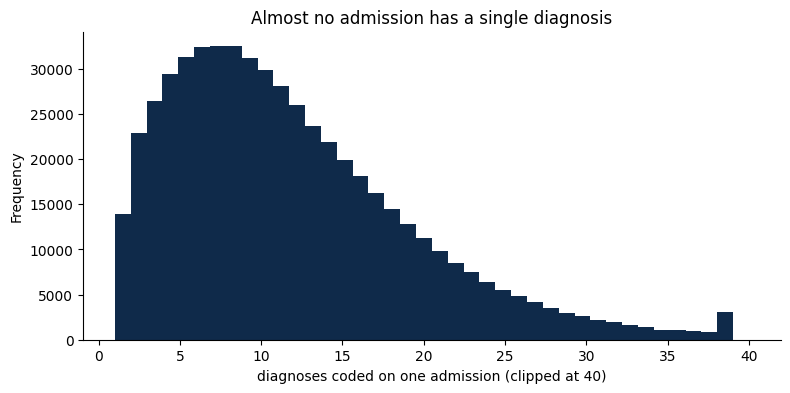

In [11]:
per_adm = dx.groupby("hadm_id").size()

print("DIAGNOSES CODED PER ADMISSION")
print(f"  mean {per_adm.mean():.1f}   median {per_adm.median():.0f}   "
      f"min {per_adm.min()}   max {per_adm.max()}")
print("  percentiles:", {f"p{p}": int(np.percentile(per_adm, p))
                         for p in (5, 10, 25, 50, 75, 90, 95, 99)})
print()
print(f"  exactly ONE diagnosis : {(per_adm == 1).sum():>8,}  ({(per_adm == 1).mean():.2%})")
for k in (2, 5, 10, 15, 20, 30):
    print(f"  {k:>2} or more           : {(per_adm >= k).sum():>8,}  ({(per_adm >= k).mean():.1%})")

ax = per_adm.clip(upper=40).plot(kind="hist", bins=40, figsize=(9, 4), color="#0F2A4A")
ax.set_xlabel("diagnoses coded on one admission (clipped at 40)")
ax.set_title("Almost no admission has a single diagnosis")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

In [12]:
def show_admission(hadm_id, header):
    rows = dx[dx.hadm_id == hadm_id].sort_values("seq_num")
    print("=" * 100)
    print(f"{header}   |   admission {hadm_id}   |   {len(rows)} diagnoses")
    print("=" * 100)
    for _, r in rows.iterrows():
        role = "PRINCIPAL" if r.seq_num == 1 else f"  seq {int(r.seq_num):>2}"
        print(f"  {role}  {r.icd_code:<9} ICD-{r.icd_version}  {r.long_title[:74]}")
        print(f"{'':>14}{'':<9}         -> {r.chapter}")
    print(f"\n  chapters spanned: {rows.chapter.nunique()}   "
          f"categories spanned: {rows.category.nunique()}\n")

single = per_adm[per_adm == 1]
if len(single):
    show_admission(single.index[0], "SINGLE-DIAGNOSIS ADMISSION -- the 1% case")

typical = per_adm[per_adm == int(per_adm.median())]
show_admission(typical.index[0], "TYPICAL ADMISSION -- the median case")

show_admission(per_adm.idxmax(), "MOST COMPLEX ADMISSION IN THE DATA")

SINGLE-DIAGNOSIS ADMISSION -- the 1% case   |   admission 20004705   |   1 diagnoses
  PRINCIPAL  42731     ICD-9  Atrial fibrillation
                                -> Circulatory system

  chapters spanned: 1   categories spanned: 1

TYPICAL ADMISSION -- the median case   |   admission 20000024   |   10 diagnoses
  PRINCIPAL  D500      ICD-10  Iron deficiency anemia secondary to blood loss (chronic)
                                -> Blood and immune mechanism
    seq  2  K521      ICD-10  Toxic gastroenteritis and colitis
                                -> Digestive system
    seq  3  I10       ICD-10  Essential (primary) hypertension
                                -> Circulatory system
    seq  4  E538      ICD-10  Deficiency of other specified B group vitamins
                                -> Endocrine, nutritional and metabolic
    seq  5  M810      ICD-10  Age-related osteoporosis without current pathological fracture
                                -> Musculoskeletal system

## 6. How far does one admission spread across the hierarchy?

A patient is not "a circulatory patient". Their codes scatter across the tree, and the number of
distinct **chapters** on one admission is a blunt but useful measure of how many organ systems
are in play at once.

In [13]:
spread = (dx.groupby("hadm_id")
            .agg(diagnoses=("icd_code", "size"),
                 chapters=("chapter", "nunique"),
                 categories=("category", "nunique")))

print("DISTINCT CHAPTERS PER ADMISSION")
c = spread.chapters.value_counts().sort_index()
for k, n in c.items():
    print(f"  {k:>2} chapter(s) : {n:>8,}  ({n/len(spread):>6.1%})")
print(f"\n  2 or more   : {(spread.chapters >= 2).sum():>8,}  ({(spread.chapters >= 2).mean():.1%})")
print(f"  5 or more   : {(spread.chapters >= 5).sum():>8,}  ({(spread.chapters >= 5).mean():.1%})")
print(f"\n  mean chapters per admission   : {spread.chapters.mean():.1f}")
print(f"  mean categories per admission : {spread.categories.mean():.1f}")

DISTINCT CHAPTERS PER ADMISSION
   1 chapter(s) :   21,403  (  3.9%)
   2 chapter(s) :   47,656  (  8.7%)
   3 chapter(s) :   54,980  ( 10.1%)
   4 chapter(s) :   60,297  ( 11.1%)
   5 chapter(s) :   63,942  ( 11.7%)
   6 chapter(s) :   65,019  ( 11.9%)
   7 chapter(s) :   60,956  ( 11.2%)
   8 chapter(s) :   53,194  (  9.8%)
   9 chapter(s) :   41,983  (  7.7%)
  10 chapter(s) :   31,412  (  5.8%)
  11 chapter(s) :   20,945  (  3.8%)
  12 chapter(s) :   13,045  (  2.4%)
  13 chapter(s) :    6,961  (  1.3%)
  14 chapter(s) :    2,891  (  0.5%)
  15 chapter(s) :      713  (  0.1%)
  16 chapter(s) :       97  (  0.0%)
  17 chapter(s) :        3  (  0.0%)

  2 or more   :  524,094  (96.1%)
  5 or more   :  361,161  (66.2%)

  mean chapters per admission   : 6.1
  mean categories per admission : 10.8


In [14]:
# Which chapters travel together. Co-occurrence is counted per ADMISSION: for
# each pair of chapters, how many admissions carry at least one code from both.
top_chapters = list(per_chapter.index[:12])
pairs = Counter()
for _, grp in dx[dx.chapter.isin(top_chapters)].groupby("hadm_id"):
    present = sorted(set(grp.chapter))
    for i in range(len(present)):
        for j in range(i + 1, len(present)):
            pairs[(present[i], present[j])] += 1

matrix = pd.DataFrame(0, index=top_chapters, columns=top_chapters, dtype=int)
for (a, b), n in pairs.items():
    matrix.loc[a, b] = n
    matrix.loc[b, a] = n

print("MOST COMMON CHAPTER PAIRS  (admissions carrying both)")
for (a, b), n in pairs.most_common(15):
    print(f"  {n:>8,}   {a}  +  {b}")

short = [c[:26] for c in matrix.columns]
styled = matrix.copy()
styled.index, styled.columns = short, short
styled

MOST COMMON CHAPTER PAIRS  (admissions carrying both)
   284,651   Circulatory system  +  Factors influencing health status
   280,483   Circulatory system  +  Endocrine, nutritional and metabolic
   280,480   Endocrine, nutritional and metabolic  +  Factors influencing health status
   201,862   Factors influencing health status  +  Symptoms, signs and abnormal findings
   188,238   Circulatory system  +  Symptoms, signs and abnormal findings
   184,055   Digestive system  +  Factors influencing health status
   183,760   Endocrine, nutritional and metabolic  +  Symptoms, signs and abnormal findings
   176,546   Factors influencing health status  +  Mental, behavioural and neurodevelopmental
   173,121   Digestive system  +  Endocrine, nutritional and metabolic
   170,888   Circulatory system  +  Digestive system
   167,229   Factors influencing health status  +  Nervous system and sense organs
   160,530   Circulatory system  +  Genitourinary system
   159,941   Factors influencing h

,Factors influencing health,Circulatory system,"Endocrine, nutritional and","Symptoms, signs and abnorm","Mental, behavioural and ne",Digestive system,Nervous system and sense o,Genitourinary system,External causes of morbidi,Respiratory system,Musculoskeletal system and,Blood and immune mechanism
Factors influencing health,0,284651,280480,201862,176546,184055,167229,159941,113466,129501,128185,143654
Circulatory system,284651,0,280483,188238,149066,170888,156369,160530,106213,124838,123686,136849
"Endocrine, nutritional and",280480,280483,0,183760,149036,173121,154923,156129,102478,122076,119947,136592
"Symptoms, signs and abnorm",201862,188238,183760,0,127310,125956,117265,108882,79448,91623,87970,103949
"Mental, behavioural and ne",176546,149066,149036,127310,0,108902,106115,82183,70556,79181,75107,79469
Digestive system,184055,170888,173121,125956,108902,0,103154,98998,68381,84561,80469,100287
Nervous system and sense o,167229,156369,154923,117265,106115,103154,0,91653,65065,77416,83261,80925
Genitourinary system,159941,160530,156129,108882,82183,98998,91653,0,61972,73437,68058,93535
External causes of morbidi,113466,106213,102478,79448,70556,68381,65065,61972,0,50876,51945,61472
Respiratory system,129501,124838,122076,91623,79181,84561,77416,73437,50876,0,57752,69604


In [15]:
# The same question one level down: which specific CODES co-occur. This is the
# comorbidity pattern a care programme would actually design around.
CAP = 200_000   # keep the pair explosion bounded on the full dataset
sample_adm = dx.hadm_id.drop_duplicates()
if len(sample_adm) > CAP:
    sample_adm = sample_adm.sample(CAP, random_state=42)
sub = dx[dx.hadm_id.isin(set(sample_adm))]

title_of = dict(zip(sub.icd_code, sub.long_title))
code_pairs = Counter()
for _, grp in sub.groupby("hadm_id"):
    codes = sorted(set(grp.icd_code))
    if len(codes) > 25:      # skip the extreme tail, it dominates the count
        continue
    for i in range(len(codes)):
        for j in range(i + 1, len(codes)):
            code_pairs[(codes[i], codes[j])] += 1

print(f"TOP 20 CO-OCCURRING CODE PAIRS  (from {sub.hadm_id.nunique():,} admissions)\n")
for (a, b), n in code_pairs.most_common(20):
    print(f"  {n:>7,}   {a:<8} {title_of[a][:42]:<44} + {b:<8} {title_of[b][:42]}")

TOP 20 CO-OCCURRING CODE PAIRS  (from 200,000 admissions)

   13,633   E785     Hyperlipidemia, unspecified                  + I10      Essential (primary) hypertension
   13,591   2724     Other and unspecified hyperlipidemia         + 4019     Unspecified essential hypertension
    9,062   E785     Hyperlipidemia, unspecified                  + Z87891   Personal history of nicotine dependence
    8,487   25000    Diabetes mellitus without mention of compl   + 4019     Unspecified essential hypertension
    7,939   4019     Unspecified essential hypertension           + 53081    Esophageal reflux
    7,872   I10      Essential (primary) hypertension             + Z87891   Personal history of nicotine dependence
    7,778   E785     Hyperlipidemia, unspecified                  + K219     Gastro-esophageal reflux disease without e
    7,318   I10      Essential (primary) hypertension             + K219     Gastro-esophageal reflux disease without e
    7,182   E785     Hyperlipidemia, u

## 7. Comorbidity burden per patient

Codes belong to admissions, so a patient with several stays accumulates a wider set than any
single admission shows.

In [16]:
per_patient = dx.groupby("subject_id").agg(
    admissions=("hadm_id", "nunique"),
    diagnosis_rows=("icd_code", "size"),
    distinct_codes=("icd_code", "nunique"),
    distinct_chapters=("chapter", "nunique"))

print("PER PATIENT, ACROSS ALL THEIR ADMISSIONS")
print(per_patient.describe(percentiles=[.25, .5, .75, .9, .99]).round(1).to_string())
print()
print(f"  patients with 1 admission only : {(per_patient.admissions == 1).mean():.1%}")
print(f"  patients touching 5+ chapters  : {(per_patient.distinct_chapters >= 5).mean():.1%}")
print(f"  most codes carried by one patient : {per_patient.distinct_codes.max():,}")

PER PATIENT, ACROSS ALL THEIR ADMISSIONS
       admissions  diagnosis_rows  distinct_codes  distinct_chapters
count    223291.0        223291.0        223291.0           223291.0
mean          2.4            28.5            20.2                7.0
std           3.6            54.2            23.8                3.9
min           1.0             1.0             1.0                1.0
25%           1.0             7.0             6.0                4.0
50%           1.0            13.0            13.0                6.0
75%           3.0            29.0            25.0               10.0
90%           5.0            63.0            45.0               13.0
99%          16.0           246.1           117.0               16.0
max         238.0          2396.0           477.0               19.0

  patients with 1 admission only : 55.2%
  patients touching 5+ chapters  : 68.1%
  most codes carried by one patient : 477


## 8. Export

Everything above, written to `/kaggle/working` as CSVs. Download them from the notebook's
**Output** tab, or commit the notebook and pull the files from the version.

In [17]:
OUT = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."

per_chapter.to_csv(f"{OUT}/icd_chapters_summary.csv")

full_index = (dx.groupby(["chapter", "category", "icd_code", "icd_version", "long_title"])
                .agg(admissions=("hadm_id", "nunique"), patients=("subject_id", "nunique"))
                .reset_index()
                .sort_values(["chapter", "admissions"], ascending=[True, False]))
full_index.to_csv(f"{OUT}/icd_full_index.csv", index=False)

principal_index = (dx[dx.seq_num == 1]
                   .groupby(["chapter", "icd_code", "icd_version", "long_title"])
                   .hadm_id.nunique().rename("admissions").reset_index()
                   .sort_values("admissions", ascending=False))
principal_index.to_csv(f"{OUT}/icd_principal_index.csv", index=False)

spread.to_csv(f"{OUT}/admission_diagnosis_spread.csv")

print("written to", OUT)
for f in ("icd_chapters_summary.csv", "icd_full_index.csv",
          "icd_principal_index.csv", "admission_diagnosis_spread.csv"):
    print(f"  {f:<34} {os.path.getsize(f'{OUT}/{f}'):>12,} bytes")
print(f"\nfull index rows: {len(full_index):,}   principal-only rows: {len(principal_index):,}")

written to /kaggle/working
  icd_chapters_summary.csv                  1,320 bytes
  icd_full_index.csv                    2,999,970 bytes
  icd_principal_index.csv               1,350,279 bytes
  admission_diagnosis_spread.csv        8,826,303 bytes

full index rows: 28,583   principal-only rows: 14,222


## 9. The numbers to bring back

Paste this block back into the Preventra project — it is the summary the documentation in
`docs/mimic/mimic_disease_landscape.md` is waiting on, measured on the full dataset rather than on the
2,000-patient loaded cohort.

In [18]:
per_adm = dx.groupby("hadm_id").size()
lines = [
    "MIMIC-IV ICD SUMMARY",
    f"  source file            : {os.path.basename(dx_path)}  ({scale})",
    f"  diagnosis rows         : {len(dx):,}",
    f"  admissions             : {dx.hadm_id.nunique():,}",
    f"  patients               : {dx.subject_id.nunique():,}",
    "",
    f"  distinct ICD codes     : {dx.icd_code.nunique():,}",
    f"  distinct categories    : {dx.category.nunique():,}",
    f"  chapters present       : {dx.chapter.nunique()}",
    f"  ICD-9 / ICD-10 rows    : {(dx.icd_version == 9).sum():,} / {(dx.icd_version == 10).sum():,}",
    "",
    f"  diagnoses per admission: mean {per_adm.mean():.1f}, median {per_adm.median():.0f}, max {per_adm.max()}",
    f"  single-diagnosis stays : {(per_adm == 1).mean():.2%}",
    f"  10+ diagnoses          : {(per_adm >= 10).mean():.1%}",
    f"  chapters per admission : mean {spread.chapters.mean():.1f}, "
    f"{(spread.chapters >= 2).mean():.1%} span 2 or more",
    "",
    "  largest chapters by distinct codes:",
]
for chapter, row in per_chapter.sort_values("distinct_codes", ascending=False).head(8).iterrows():
    lines.append(f"    {chapter:<46} {int(row.distinct_codes):>6,} codes  "
                 f"{int(row.admissions):>9,} admissions")

report = "\n".join(lines)
print(report)
open(f"{OUT}/mimic_icd_summary.txt", "w").write(report + "\n")

MIMIC-IV ICD SUMMARY
  source file            : diagnoses_icd.csv  (FULL MIMIC-IV)
  diagnosis rows         : 6,364,488
  admissions             : 545,497
  patients               : 223,291

  distinct ICD codes     : 28,562
  distinct categories    : 2,622
  chapters present       : 20
  ICD-9 / ICD-10 rows    : 2,908,741 / 3,455,747

  diagnoses per admission: mean 11.7, median 10, max 57
  single-diagnosis stays : 2.56%
  10+ diagnoses          : 53.7%
  chapters per admission : mean 6.1, 96.1% span 2 or more

  largest chapters by distinct codes:
    Injury and poisoning                            7,486 codes    140,711 admissions
    Musculoskeletal system and connective tissue    2,652 codes    160,528 admissions
    Nervous system and sense organs                 2,425 codes    203,215 admissions
    Neoplasms                                       1,808 codes     97,090 admissions
    External causes of morbidity                    1,779 codes    150,534 admissions
    Factors i

1245